# South Korea R-C-K model

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install statsmodels


In [4]:
pip install requests

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)

   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   -------------------------------- ------- 4/5 [requests]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import requests


In [63]:
# read the excel file 
df = pd.read_excel(r'C:\Users\dell\OneDrive\Documents\SSE\GD\pwt110.xlsx', sheet_name= 'Sheet2')

In [64]:
df.index = pd.PeriodIndex(df['year'], freq='Y')
df.drop(columns=['year'], inplace=True)


In [65]:
df.columns


Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf'],
      dtype='str')

# barro regression


In [74]:
# tacking log of the level variable
df['log_rgdpo'] = np.log(df['rgdpo'])

# lag of the log variable
df['log_rgdpo_lag1'] = df['log_rgdpo'].shift(1)

# growth rate of the level variable
df['rgdpo_growth'] = df['log_rgdpo'] - df['log_rgdpo_lag1']

In [67]:
# unconditional regression
X = df['log_rgdpo_lag1']# independent variable 
y = df['rgdpo_growth'] # dependent variable

# add a constant to the independent variable
X = sm.add_constant(X)

unc_model = sm.OLS(y, X, missing='drop').fit()
print(unc_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpo_growth   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     8.535
Date:                Sat, 14 Mar 2026   Prob (F-statistic):            0.00481
Time:                        02:01:47   Log-Likelihood:                 99.180
No. Observations:                  66   AIC:                            -194.4
Df Residuals:                      64   BIC:                            -190.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2405      0.059      4.

In [109]:
df['gfcf'] = pd.to_numeric(df['gfcf'], errors='coerce')
df['export'] = pd.to_numeric(df['export'], errors='coerce')
df['trade'] = pd.to_numeric(df['trade'], errors='coerce')

# creating other variables for the regression
df['emp_growth'] = df['emp']- df['emp'].shift(1)
df['log_gfcf'] = np.log(df['gfcf'])
# creating (n+g+delta) variable
df['n_g_delta'] = df['emp_growth'] + df['rtfpna'] + df['delta']
df['log_n_g_delta'] = np.log(df['n_g_delta'])
# conditional regression
X_cond = df[['log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']] # independent variables

#per capita output growth as the dependent variable
df['rgdpo_capita'] = df['rgdpo'] / df['emp']


y_cond = df['rgdpo_growth'] # dependent variable
x_cond = sm.add_constant(X_cond)



c:\Users\dell\OneDrive\Documents\SSE\GD\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
print(x_cond.dtypes)

const             float64
log_rgdpo_lag1    float64
log_n_g_delta     float64
gfcf              float64
dtype: object


In [110]:
cond_model = sm.OLS(y_cond, x_cond, missing='drop').fit()
print(cond_model.summary())

                            OLS Regression Results                            
Dep. Variable:           rgdpo_growth   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     17.98
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.10e-08
Time:                        02:26:39   Log-Likelihood:                 116.73
No. Observations:                  63   AIC:                            -225.5
Df Residuals:                      59   BIC:                            -216.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1772      0.090      1.

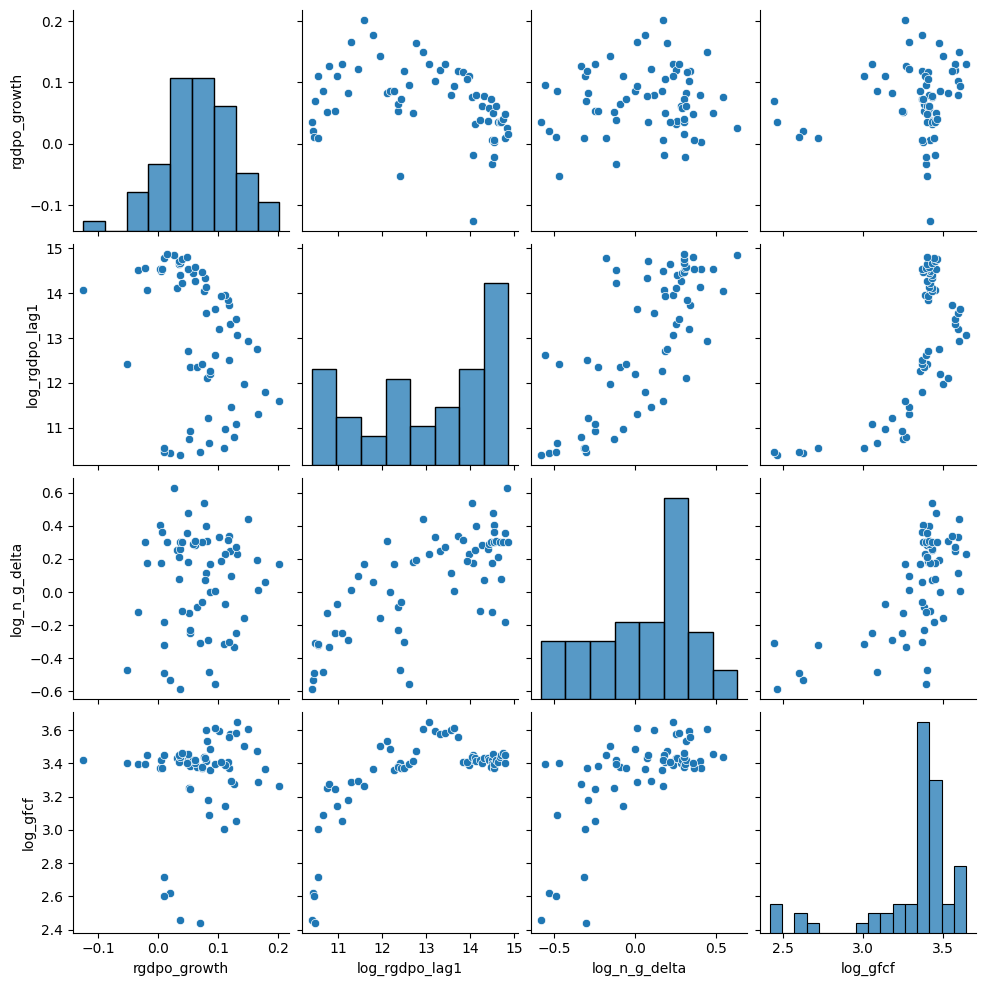

In [130]:
# relationship between each independent variable and the dependent variable
sns.pairplot(df[['rgdpo_growth', 'log_rgdpo_lag1', 'log_n_g_delta', 'log_gfcf']])
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_2520\1658878096.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


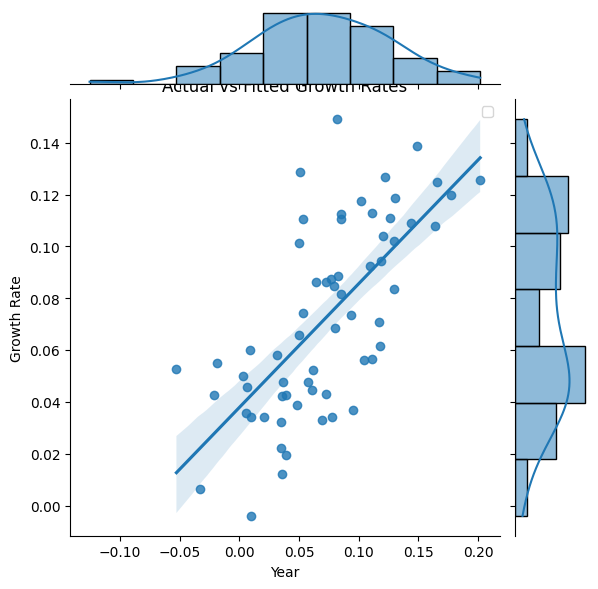

In [138]:
# plot fitted and actual values actter and line graph
df['fitted_values'] = cond_model.fittedvalues
sns.jointplot(x=df['rgdpo_growth'], y=df['fitted_values'], kind='reg')
plt.title('Actual vs Fitted Growth Rates') 
plt.xlabel('Year')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()

In [142]:
sns.regplot(
    data=df,
    x=df.index.to_timestamp(),
    y="Breakeven",
    scatter_kws={"color":"green"},
    line_kws={"color":"red"},
    lowess=True)

KeyError: 'Breakeven'

### Distribution of real GDP

C:\Users\dell\AppData\Local\Temp\ipykernel_2520\1578337918.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rgdpo'], label='Data Points');


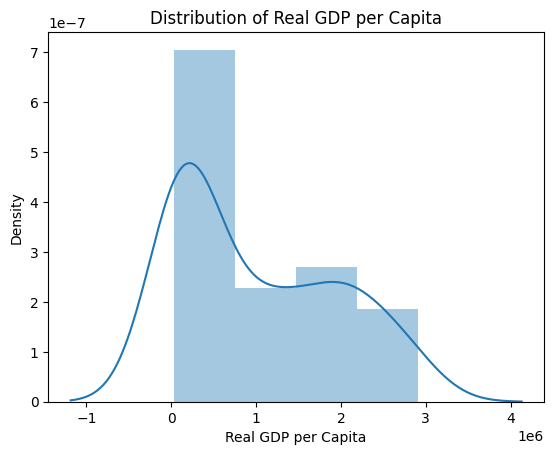

In [146]:
sns.distplot(df['rgdpo'], label='Data Points');
plt.title('Distribution of Real GDP per Capita')
plt.xlabel('Real GDP per Capita') 
plt.ylabel('Density')
plt.show()

#### production function

In [ ]:
df.columns

Index(['rgdpe', 'rgdpo', 'cgdpe', 'cgdpo', 'cn', 'rgdpna', 'rconna', 'rdana',
       'rnna', 'pop', 'emp', 'irr', 'delta', 'rtfpna', 'export', 'trade',
       'high_exports', 'gfcf', 'log_rgdpo', 'log_rgdpo_lag1', 'rgdpo_growth',
       'emp_growth', 'n_g_delta', 'rgdpo_capita_growth', 'rgdpo_capita',
       'log_n_g_delta', 'log_gfcf', 'fitted_values'],
      dtype='str')

In [152]:
# to identify alpha,beta 
df['log_emp'] = np.log(df['emp'])
df['log_capital'] = np.log(df['rnna'])

x_pro = df[['log_capital', 'log_emp']]
x_pro = sm.add_constant(x_pro)
y_pro = np.log(df['log_rgdpo'])

pro_model = sm.OLS(y_pro, x_pro, missing='drop').fit()
print(pro_model.summary())



                            OLS Regression Results                            
Dep. Variable:              log_rgdpo   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     7377.
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           2.15e-76
Time:                        03:31:30   Log-Likelihood:                 230.45
No. Observations:                  67   AIC:                            -454.9
Df Residuals:                      64   BIC:                            -448.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.7846      0.016    109.699      

In [155]:
# alpha, beta and A
alpha = pro_model.params['log_capital']
beta = pro_model.params['log_emp']
A = pro_model.params['const']

In [157]:
# production function

def production_function(K, L):
    return A * (df['rnna'] ** alpha) * (df['emp'] ** beta)

predicted_output = production_function(df['rnna'], df['emp'])
print(predicted_output)

year
1957    3.083317
1958    3.097335
1959    3.113227
1960    3.130777
1961    3.160728
          ...   
2019    4.474407
2020    4.467393
2021    4.483412
2022    4.516637
2023    4.529903
Freq: Y-DEC, Length: 67, dtype: float64


In [158]:
# per capita production function
def production_function_per_capita(K, L):
    return A * (df['rnna'] ** alpha) * (df['emp'] ** beta) / df['emp']
predicted_output_per_capita = production_function_per_capita(df['rnna'], df['emp'])
print(predicted_output_per_capita)

year
1957    0.467845
1958    0.461177
1959    0.453629
1960    0.445524
1961    0.432297
          ...   
2019    0.164940
2020    0.165943
2021    0.164251
2022    0.160610
2023    0.159278
Freq: Y-DEC, Length: 67, dtype: float64


### solow curve

In [ ]:
# plot Solow curve


## Break-even regression to identify structural changes